# 05 — Günlük Mutabakat, Fark ve Alarm Analizi

WSM Günlük Analiz tablosu (`daily.csv`) — SEL eşiği ve alarm mantığı.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'eda' and (ROOT / 'eda').exists():
    ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))

from utils.data_loader import load_all
from utils.plots import setup_style

setup_style()
daily = load_all()['daily']
daily['fark_abs'] = daily['fark'].abs()
daily['sel_asildi'] = daily['fark_abs'] > daily['sel']

In [2]:
print('Alarm oranı:', daily['alarm'].mean())
print('SEL aşım oranı (manuel kontrol):', daily['sel_asildi'].mean())
print('Alarm ile SEL tutarlı mı:', (daily['alarm'] == daily['sel_asildi'].astype(int)).mean())

Alarm oranı: 0.059375
SEL aşım oranı (manuel kontrol): 0.059375
Alarm ile SEL tutarlı mı: 1.0


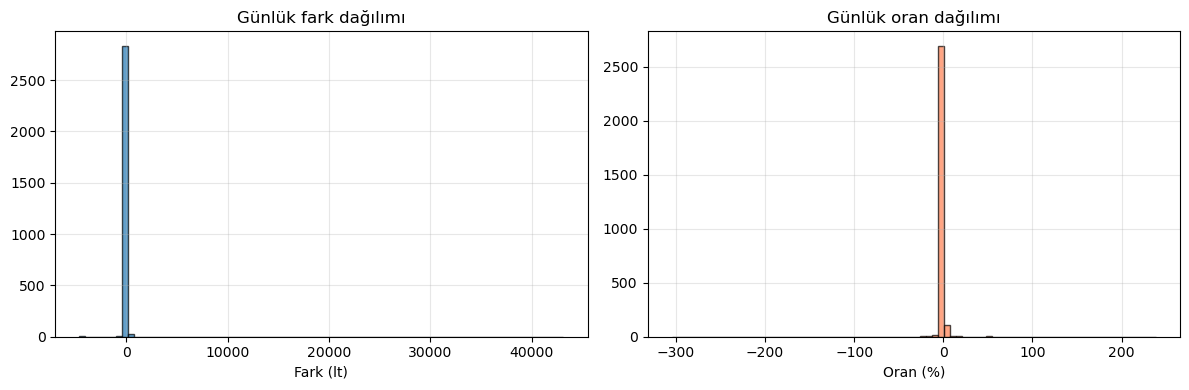

In [3]:
# Fark dağılımı
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
daily['fark'].hist(bins=80, ax=axes[0], edgecolor='k', alpha=0.7)
axes[0].set_xlabel('Fark (lt)'); axes[0].set_title('Günlük fark dağılımı')
daily['oran'].hist(bins=80, ax=axes[1], edgecolor='k', alpha=0.7, color='coral')
axes[1].set_xlabel('Oran (%)'); axes[1].set_title('Günlük oran dağılımı')
plt.tight_layout()
plt.show()

En çok alarm üreten tanklar:


,istasyon_kodu,tank_no,alarm
11,IST_003,2,16
20,IST_005,3,15
18,IST_005,1,15
26,IST_007,2,14
28,IST_007,4,10
16,IST_004,4,9
14,IST_004,2,9
10,IST_003,1,8
5,IST_002,1,8
17,IST_004,5,7


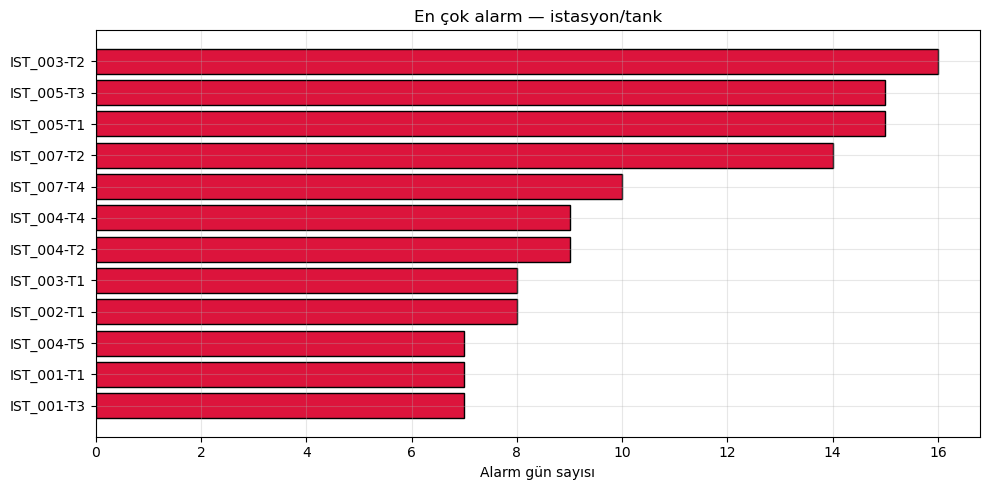

In [4]:
# Alarm sayısı — istasyon × tank
alarm_cnt = daily.groupby(['istasyon_kodu','tank_no'])['alarm'].sum().reset_index()
alarm_cnt = alarm_cnt.sort_values('alarm', ascending=False)
print('En çok alarm üreten tanklar:')
display(alarm_cnt.head(15))

plt.figure(figsize=(10, 5))
top = alarm_cnt.head(12)
labels = top['istasyon_kodu'] + '-T' + top['tank_no'].astype(str)
plt.barh(labels, top['alarm'], color='crimson', edgecolor='k')
plt.xlabel('Alarm gün sayısı')
plt.title('En çok alarm — istasyon/tank')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

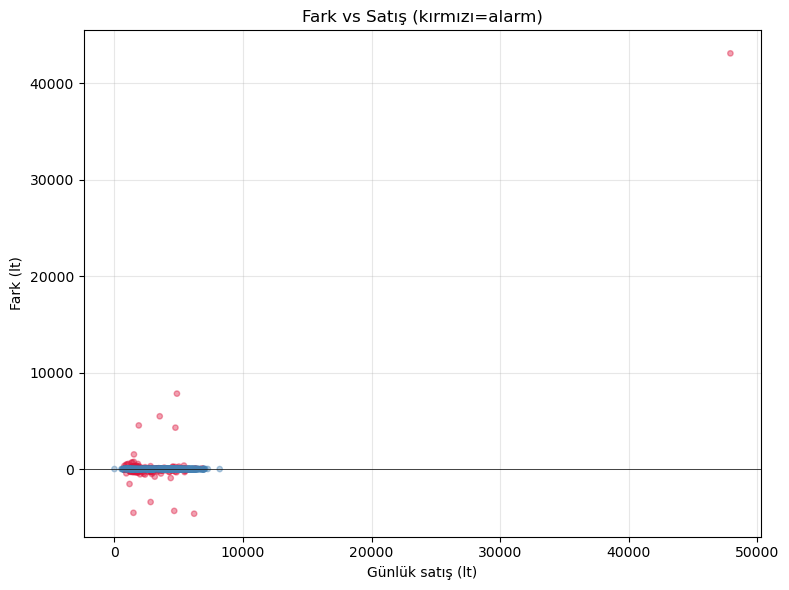

In [5]:
# Fark vs satış scatter
plt.figure(figsize=(8, 6))
colors = daily['alarm'].map({0: 'steelblue', 1: 'crimson'})
plt.scatter(daily['satis'], daily['fark'], c=colors, alpha=0.4, s=15)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('Günlük satış (lt)')
plt.ylabel('Fark (lt)')
plt.title('Fark vs Satış (kırmızı=alarm)')
plt.tight_layout()
plt.show()

In [6]:
# Mutabakat denklemi kontrolü: fark = satis - azalma
daily['fark_hesap'] = daily['satis'] - daily['azalma_miktari']
daily['fark_residual'] = daily['fark'] - daily['fark_hesap']
print('Fark denklemi max residual:', daily['fark_residual'].abs().max())

Fark denklemi max residual: 7.275957614183426e-12


Sonraki: envanter, su, sıcaklık (`06_envanter_su_sicaklik.ipynb`).